In [2]:
import os
import pickle
from typing import Literal
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.sparse.csgraph as csgraph
import torch
from torch_geometric.data import Data, InMemoryDataset

In [3]:
DATA_DIR = "../datasets"

DATASET_CONFIG = {
    "METR-LA": {
        "group_key": "df",
        "h5_path":  f"{DATA_DIR}/raw/metr_la/metr_la.h5",
        "adj_path": f"{DATA_DIR}/raw/metr_la/adj_metr_la.pkl",
        "meta_path": None,
        "pyg_path": f"{DATA_DIR}/processed/metr_la/metr_la.pt",
    },
    "PEMS-BAY": {
        "group_key": "speed",
        "h5_path":  f"{DATA_DIR}/raw/pems_bay/pems_bay.h5",
        "adj_path": f"{DATA_DIR}/raw/pems_bay/adj_mx_bay.pkl",
        "meta_path": f"{DATA_DIR}/raw/pems_bay/pems_bay_meta.h5",
        "pyg_path": f"{DATA_DIR}/processed/pems_bay/pems_bay.pt",
    },
}

In [4]:
def load_traffic_h5(dataset: Literal["METR-LA", "PEMS-BAY"]) -> pd.DataFrame:
    config = DATASET_CONFIG[dataset]

    with h5py.File(config["h5_path"], "r") as f:
        group = f[config["group_key"]]
        values = group["block0_values"][:]
        sensor_ids = group["axis0"][:]
        timestamps = group["axis1"][:]

    times = pd.to_datetime(timestamps, unit="ns")
    N = len(sensor_ids)
    if values.shape[0] == N:
        values = values.T

    df = pd.DataFrame(values, index=times, columns=sensor_ids)
    df.columns = df.columns.astype(str) # sensor IDs to str as sensor ID to idx map uses string IDs
    
    return df

In [5]:
# usage
metr_df = load_traffic_h5("METR-LA")
pems_df = load_traffic_h5("PEMS-BAY")

In [6]:
def load_adj_data(dataset: Literal["METR-LA", "PEMS-BAY"]):
    """
    Returns:
        sensor_ids        : list of sensor ID strings, length N
        sensor_id_to_idx  : dict mapping sensor ID → node index (0..N-1)
        adj_mx            : np.ndarray, shape (N, N), weights in [0, 1]
    """
    config = DATASET_CONFIG[dataset]

    with open(config["adj_path"], "rb") as f:
        adj_data = pickle.load(f, encoding="latin1")

    sensor_ids, sensor_id_to_idx, adj_mx = adj_data

    return sensor_ids, sensor_id_to_idx, adj_mx

In [7]:
metr_sensor_ids, metr_sensor_id_to_idx, metr_adj_mx = load_adj_data("METR-LA")
print("METR-LA:", len(metr_sensor_ids), metr_adj_mx.shape, list(metr_sensor_id_to_idx.items())[:3])

pems_sensor_ids, pems_sensor_id_to_idx, pems_adj_mx = load_adj_data("PEMS-BAY")
print("PEMS-BAY:", len(pems_sensor_ids), pems_adj_mx.shape, list(pems_sensor_id_to_idx.items())[:3])

METR-LA: 207 (207, 207) [('717099', 110), ('773869', 0), ('767541', 1)]
PEMS-BAY: 325 (325, 325) [('401391', 148), ('409528', 317), ('407157', 263)]


In [8]:
def load_sensor_metadata(dataset: Literal["METR-LA", "PEMS-BAY"]) -> pd.DataFrame | None:
    """
    Loads sensor metadata (location, sensor ID, etc.) if available.

    Returns:
        pd.DataFrame with sensor info, or None if not available for this dataset.
    """
    meta_path = DATASET_CONFIG[dataset]["meta_path"]

    if meta_path is None:
        print(f"No sensor metadata available for {dataset}.")
        return None

    df = pd.read_hdf(meta_path)
    return df

In [9]:
pems_meta_df = load_sensor_metadata("PEMS-BAY")
pems_meta_df.head()

,Fwy,Dir,District,County,City,State_PM,Abs_PM,Latitude,Longitude,Length,Type,Lanes,Name,User_ID_1,User_ID_2,User_ID_3,User_ID_4
sensor_id,,,,,,,,,,,,,,,,,
400649,17,N,4,85,44112.0,9.06,21.613,37.251741,-121.958118,0.850,ML,2,LARK AVE,DT185,L2-N-37-017-00906,998009,417770
400715,17,N,4,85,44112.0,9.4,21.953,37.256205,-121.955355,0.245,ML,2,SB 85 rm-n-conn,DT244,L2-N-37-017-00940,998013,417774
400240,17,N,4,85,44112.0,9.55,22.103,37.258184,-121.953853,0.535,ML,3,NB 85 rm-n-conn,DT260,L3-N-37-017-00955,998017,420767
403329,17,N,4,85,10340.0,10.47,23.023,37.270267,-121.947353,0.510,ML,3,Camden ave rm-n-loop,DTB25,L3-N-37-017-01047,997278,430594
400436,17,N,4,85,10340.0,10.57,23.123,37.271687,-121.947037,0.905,ML,3,Camden Ave rm-n-diag,DT267,l3-N-37-017-01057,998021,420772


In [10]:
def analyze_connectivity(adj_mx: np.ndarray, dataset: str):
    """
    Analyzes connectivity properties of the adjacency matrix.
    adj_mx: np.ndarray, shape (N, N), weights in [0, 1]
    """
    N = adj_mx.shape[0]
    
    # binary matrix — ignore weights for connectivity
    A = (adj_mx != 0).astype(int)
    
    # ---- sparsity ----
    total_possible = N * (N - 1)   # excluding self-loops
    total_edges    = A.sum() - A.diagonal().sum()
    sparsity       = 1 - (total_edges / total_possible)

    # ---- symmetry ----
    is_symmetric = (A == A.T).all()

    # ---- isolated sensors (no neighbors at all) ----
    degree        = A.sum(axis=1) - A.diagonal()   # exclude self-loops
    num_isolated  = (degree == 0).sum()

    # ---- connected components ----
    n_components, labels = csgraph.connected_components(A, directed=not is_symmetric)
    component_sizes      = np.bincount(labels)

    print(f"\n{dataset}")
    print(f"\tsensors          : {N}")
    print(f"\tedges            : {total_edges}")
    print(f"\tsparsity         : {sparsity * 100:.1f}%")
    print(f"\tsymmetric        : {is_symmetric}")
    print(f"\tisolated sensors : {num_isolated}")
    print(f"\tcomponents       : {n_components}")
    print(f"\tcomponent sizes  : {sorted(component_sizes, reverse=True)}")

analyze_connectivity(metr_adj_mx, "METR-LA")
analyze_connectivity(pems_adj_mx, "PEMS-BAY")


METR-LA
	sensors          : 207
	edges            : 1515
	sparsity         : 96.4%
	symmetric        : False
	isolated sensors : 5
	components       : 2
	component sizes  : [206, 1]

PEMS-BAY
	sensors          : 325
	edges            : 2369
	sparsity         : 97.8%
	symmetric        : False
	isolated sensors : 12
	components       : 7
	component sizes  : [319, 1, 1, 1, 1, 1, 1]



METR-LA
  out-degree  min/mean/max : 0 / 7.32 / 18
  in-degree   min/mean/max : 0 / 7.32 / 17
  hubs (top 5)    : [(16, 18), (4, 15), (187, 15), (195, 15), (38, 14)]
  isolated sensors: 5
  avg neighbors   : 7.32

PEMS-BAY
  out-degree  min/mean/max : 0 / 7.29 / 22
  in-degree   min/mean/max : 0 / 7.29 / 22
  hubs (top 5)    : [(217, 22), (235, 20), (145, 20), (68, 19), (139, 18)]
  isolated sensors: 12
  avg neighbors   : 7.29


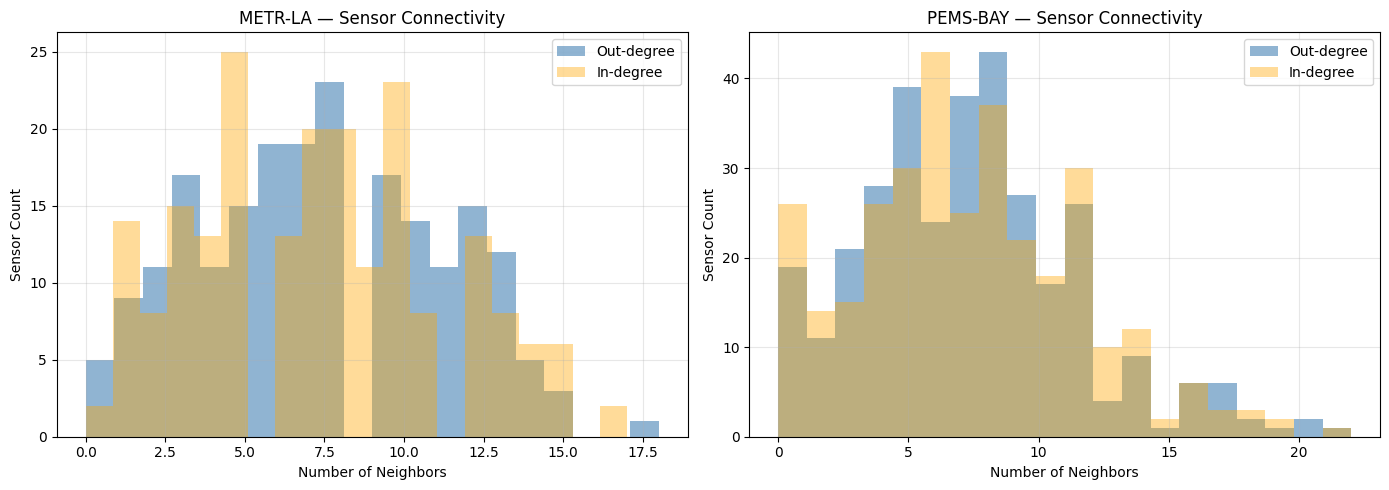

In [11]:
def analyze_degree(adj_mx: np.ndarray, dataset: str, ax=None):
    """
    Analyzes degree and neighborhood properties of the adjacency matrix
    and optionally plots degree distribution.
    """
    A = (adj_mx != 0).astype(int)
    np.fill_diagonal(A, 0)   # exclude self-loops

    out_degree = A.sum(axis=1)
    in_degree  = A.sum(axis=0)

    print(f"\n{dataset}")

    # ---- degree stats ----
    print(f"  out-degree  min/mean/max : {out_degree.min()} / {out_degree.mean():.2f} / {out_degree.max()}")
    print(f"  in-degree   min/mean/max : {in_degree.min()} / {in_degree.mean():.2f} / {in_degree.max()}")

    # ---- hubs ----
    hub_indices = out_degree.argsort()[::-1][:5]
    print(f"  hubs (top 5)    : {[(i, out_degree[i]) for i in hub_indices]}")

    # ---- isolated ----
    isolated = (out_degree == 0).sum()
    print(f"  isolated sensors: {isolated}")

    print(f"  avg neighbors   : {out_degree.mean():.2f}")

    # ---- visualization ----
    if ax is not None:
        ax.hist(out_degree, bins=20, alpha=0.6, label='Out-degree', color='steelblue')
        ax.hist(in_degree,  bins=20, alpha=0.4, label='In-degree',  color='orange')
        ax.set_title(f"{dataset} — Sensor Connectivity")
        ax.set_xlabel("Number of Neighbors")
        ax.set_ylabel("Sensor Count")
        ax.legend()
        ax.grid(alpha=0.3)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)

analyze_degree(metr_adj_mx, "METR-LA",  ax=axes[0])
analyze_degree(pems_adj_mx, "PEMS-BAY", ax=axes[1])

plt.show()

In [ ]:
metr_out, metr_in = get_degrees(metr_adj)
pems_out, pems_in = get_degrees(pems_adj)

# ---------------------------
# Visualization (side-by-side)
# ---------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5), tight_layout=True)

# METR-LA
axes[0].hist(metr_out, bins=20, alpha=0.6, label='Out-degree', color='steelblue')
axes[0].hist(metr_in,  bins=20, alpha=0.4, label='In-degree',  color='orange')
axes[0].set_title("METR-LA — Sensor Connectivity")
axes[0].set_xlabel("Number of Neighbors")
axes[0].set_ylabel("Sensor Count")
axes[0].legend()
axes[0].grid(alpha=0.3)

# PEMS-BAY
axes[1].hist(pems_out, bins=20, alpha=0.6, label='Out-degree', color='steelblue')
axes[1].hist(pems_in,  bins=20, alpha=0.4, label='In-degree',  color='orange')
axes[1].set_title("PEMS-BAY — Sensor Connectivity")
axes[1].set_xlabel("Number of Neighbors")
axes[1].set_ylabel("Sensor Count")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.show()

# ---------------------------
# Print summary stats
# ---------------------------
print("METR-LA  avg degree:", np.mean(metr_out), "| max:", np.max(metr_out))
print("PEMS-BAY avg degree:", np.mean(pems_out), "| max:", np.max(pems_out))


METR-LA
  total edges : 1515
  min/mean/max: 0.100 / 0.401 / 1.000
  strong (≥0.7): 255 (16.8%)
  medium (0.3–0.7): 536 (35.4%)
  weak   (<0.3): 724 (47.8%)

PEMS-BAY
  total edges : 2369
  min/mean/max: 0.100 / 0.561 / 1.000
  strong (≥0.7): 942 (39.8%)
  medium (0.3–0.7): 743 (31.4%)
  weak   (<0.3): 684 (28.9%)


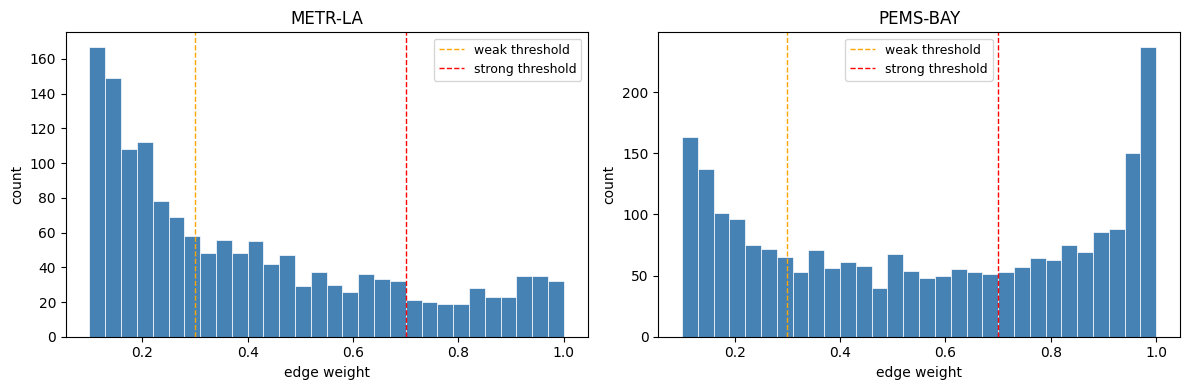

In [11]:
def analyze_weight_distribution(adj_mx: np.ndarray, dataset: str, ax=None):
    """
    Analyzes edge weight distribution of the adjacency matrix.
    adj_mx: np.ndarray, shape (N, N), weights in [0, 1]
    """
    A = adj_mx.copy()
    np.fill_diagonal(A, 0)                  # exclude self-loops

    weights = A[A > 0].flatten()            # only non-zero off-diagonal weights

    strong = (weights >= 0.7).sum()
    medium = ((weights >= 0.3) & (weights < 0.7)).sum()
    weak   = (weights < 0.3).sum()

    print(f"\n{dataset}")
    print(f"  total edges : {len(weights)}")
    print(f"  min/mean/max: {weights.min():.3f} / {weights.mean():.3f} / {weights.max():.3f}")
    print(f"  strong (≥0.7): {strong} ({strong/len(weights)*100:.1f}%)")
    print(f"  medium (0.3–0.7): {medium} ({medium/len(weights)*100:.1f}%)")
    print(f"  weak   (<0.3): {weak} ({weak/len(weights)*100:.1f}%)")

    # histogram
    if ax is None:
        _, ax = plt.subplots()
    ax.hist(weights, bins=30, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.axvline(0.3, color='orange', linestyle='--', linewidth=1, label='weak threshold')
    ax.axvline(0.7, color='red',    linestyle='--', linewidth=1, label='strong threshold')
    ax.set_title(dataset)
    ax.set_xlabel('edge weight')
    ax.set_ylabel('count')
    ax.legend(fontsize=9)


fig, axes = plt.subplots(1, 2, figsize=(12, 4), tight_layout=True)
analyze_weight_distribution(metr_adj_mx, "METR-LA",  ax=axes[0])
analyze_weight_distribution(pems_adj_mx, "PEMS-BAY", ax=axes[1])
plt.show()

In [12]:
def analyze_missing_data(df: pd.DataFrame, dataset: str):
    total           = df.size
    dead_sensors    = (df == 0).all(axis=0).sum()
    empty_timesteps = (df == 0).all(axis=1).sum()
    total_zeros     = (df == 0).sum().sum()

    print(f"{dataset}")
    print(f"\tdead sensors     : {dead_sensors} / {df.shape[1]}")
    print(f"\tempty timesteps  : {empty_timesteps} / {len(df)} ({empty_timesteps / len(df) * 100:.1f}%)")
    print(f"\ttotal zero values: {total_zeros} / {total} ({total_zeros / total * 100:.2f}%)")

analyze_missing_data(metr_df, "METR-LA")
analyze_missing_data(pems_df, "PEMS-BAY")

METR-LA
	dead sensors     : 0 / 207
	empty timesteps  : 2148 / 34272 (6.3%)
	total zero values: 575302 / 7094304 (8.11%)
PEMS-BAY
	dead sensors     : 0 / 325
	empty timesteps  : 0 / 52116 (0.0%)
	total zero values: 521 / 16937700 (0.00%)


METR-LA  min/mean/max/std: 0.33 / 58.46 / 70.00 / 13.02
PEMS-BAY  min/mean/max/std: 3.00 / 62.62 / 85.10 / 9.59


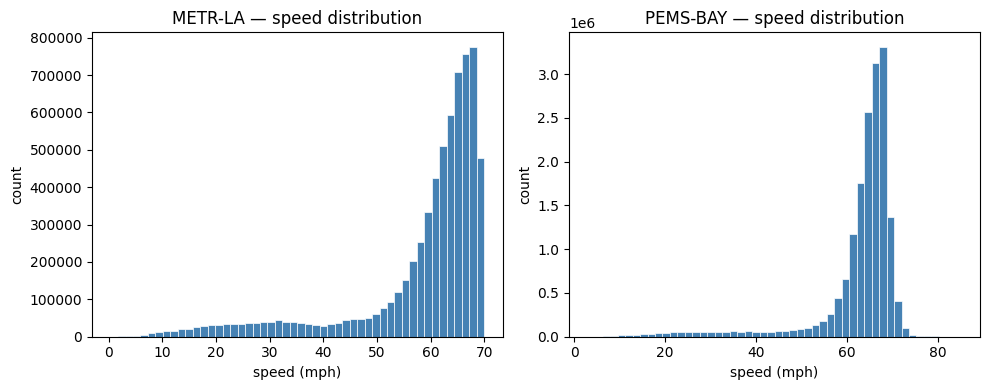

In [13]:
def analyze_speed_distribution(df: pd.DataFrame, dataset: str, ax=None):
    values = df.values.flatten()
    values = values[~np.isnan(values)]
    values = values[values > 0]

    print(f"{dataset}  min/mean/max/std: {values.min():.2f} / {values.mean():.2f} / {values.max():.2f} / {values.std():.2f}")

    if ax is None:
        _, ax = plt.subplots()
    ax.hist(values, bins=50, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(f"{dataset} — speed distribution")
    ax.set_xlabel("speed (mph)")
    ax.set_ylabel("count")

fig, axes = plt.subplots(1, 2, figsize=(10, 4), tight_layout=True)
analyze_speed_distribution(metr_df, "METR-LA",  ax=axes[0])
analyze_speed_distribution(pems_df, "PEMS-BAY", ax=axes[1])
plt.show()

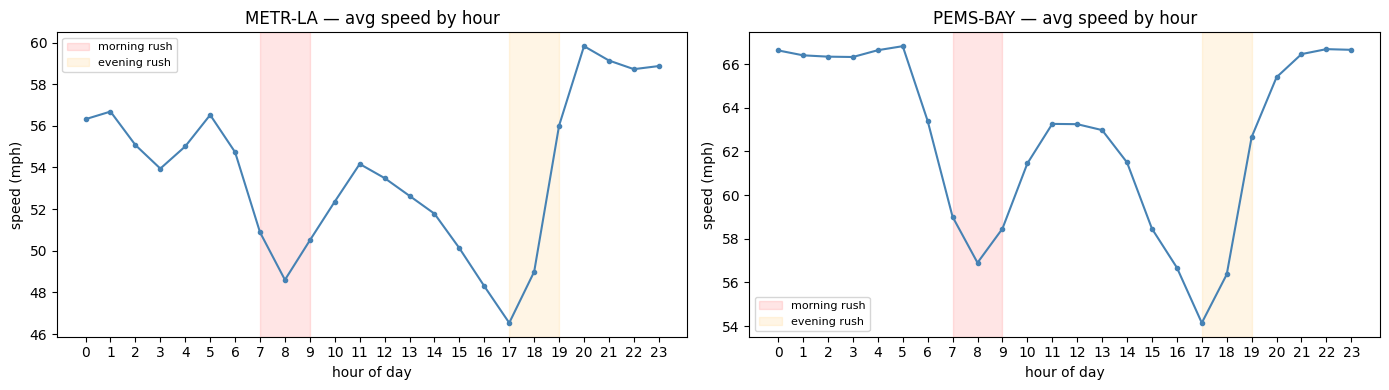

In [14]:
def analyze_rush_hour(df: pd.DataFrame, dataset: str, ax=None):
    mean_speed         = df.mean(axis=1).to_frame(name='speed')
    mean_speed['hour'] = mean_speed.index.hour
    hourly             = mean_speed.groupby('hour')['speed'].mean()

    if ax is None:
        _, ax = plt.subplots()
    ax.plot(hourly.index, hourly.values, marker='o', markersize=3, color='steelblue')
    ax.axvspan(7,  9,  alpha=0.1, color='red',    label='morning rush')
    ax.axvspan(17, 19, alpha=0.1, color='orange',  label='evening rush')
    ax.set_title(f"{dataset} — avg speed by hour")
    ax.set_xlabel("hour of day")
    ax.set_ylabel("speed (mph)")
    ax.set_xticks(range(0, 24))
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), tight_layout=True)
analyze_rush_hour(metr_df, "METR-LA",  ax=axes[0])
analyze_rush_hour(pems_df, "PEMS-BAY", ax=axes[1])
plt.show()

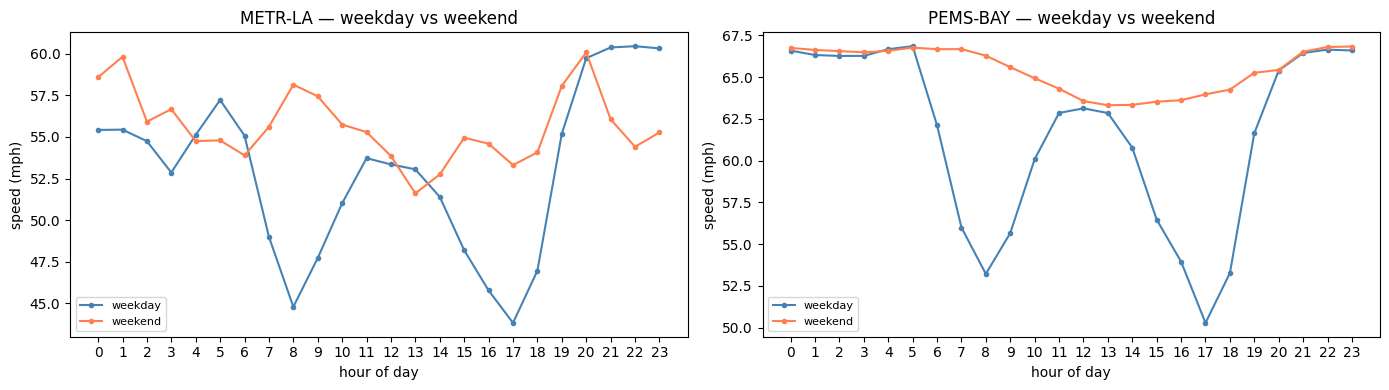

In [15]:
def analyze_weekday_weekend(df: pd.DataFrame, dataset: str, ax=None):
    mean_speed               = df.mean(axis=1).to_frame(name='speed')
    mean_speed['hour']       = mean_speed.index.hour
    mean_speed['is_weekend'] = mean_speed.index.dayofweek >= 5

    weekday = mean_speed[~mean_speed['is_weekend']].groupby('hour')['speed'].mean()
    weekend = mean_speed[ mean_speed['is_weekend']].groupby('hour')['speed'].mean()

    if ax is None:
        _, ax = plt.subplots()
    ax.plot(weekday.index, weekday.values, marker='o', markersize=3, label='weekday', color='steelblue')
    ax.plot(weekend.index, weekend.values, marker='o', markersize=3, label='weekend', color='coral')
    ax.set_title(f"{dataset} — weekday vs weekend")
    ax.set_xlabel("hour of day")
    ax.set_ylabel("speed (mph)")
    ax.set_xticks(range(0, 24))
    ax.legend(fontsize=8)

fig, axes = plt.subplots(1, 2, figsize=(14, 4), tight_layout=True)
analyze_weekday_weekend(metr_df, "METR-LA",  ax=axes[0])
analyze_weekday_weekend(pems_df, "PEMS-BAY", ax=axes[1])
plt.show()

METR-LA
  slowest sensors: [(16, 28.31), (196, 30.01), (56, 32.74), (91, 36.04), (12, 37.78)]
  fastest sensors: [(123, 62.99), (99, 62.51), (203, 62.48), (67, 62.1), (167, 61.93)]
PEMS-BAY
  slowest sensors: [(133, 53.94), (134, 54.77), (121, 55.76), (26, 56.0), (308, 56.05)]
  fastest sensors: [(253, 68.03), (24, 67.62), (0, 67.57), (321, 67.57), (27, 67.35)]


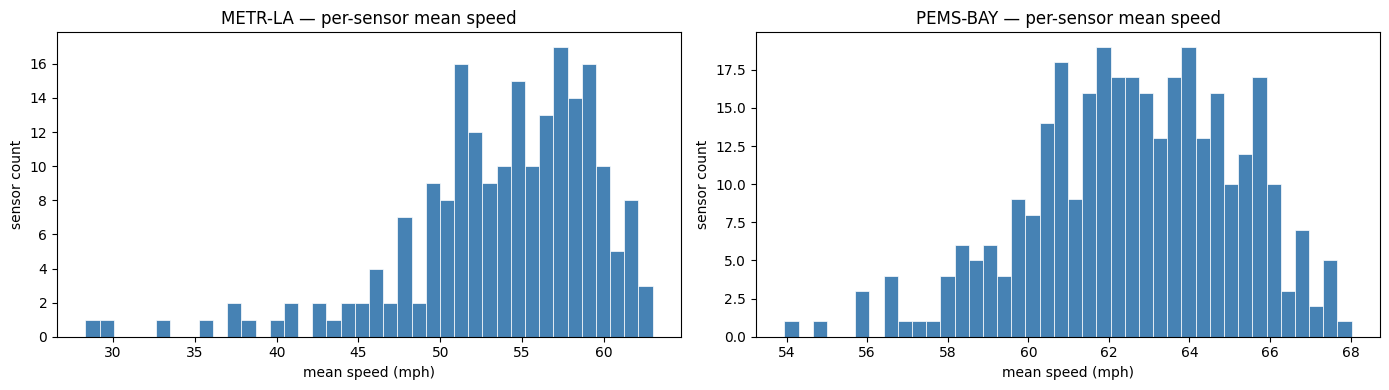

In [16]:
def analyze_per_sensor_speed(df: pd.DataFrame, dataset: str, ax=None):
    sensor_mean  = df.mean(axis=0).values
    slow_idx     = sensor_mean.argsort()[:5]
    fast_idx     = sensor_mean.argsort()[::-1][:5]

    print(f"{dataset}")
    print(f"  slowest sensors: {[(i, round(sensor_mean[i], 2)) for i in slow_idx]}")
    print(f"  fastest sensors: {[(i, round(sensor_mean[i], 2)) for i in fast_idx]}")

    if ax is None:
        _, ax = plt.subplots()
    ax.hist(sensor_mean, bins=40, color='steelblue', edgecolor='white', linewidth=0.5)
    ax.set_title(f"{dataset} — per-sensor mean speed")
    ax.set_xlabel("mean speed (mph)")
    ax.set_ylabel("sensor count")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), tight_layout=True)
analyze_per_sensor_speed(metr_df, "METR-LA",  ax=axes[0])
analyze_per_sensor_speed(pems_df, "PEMS-BAY", ax=axes[1])
plt.show()

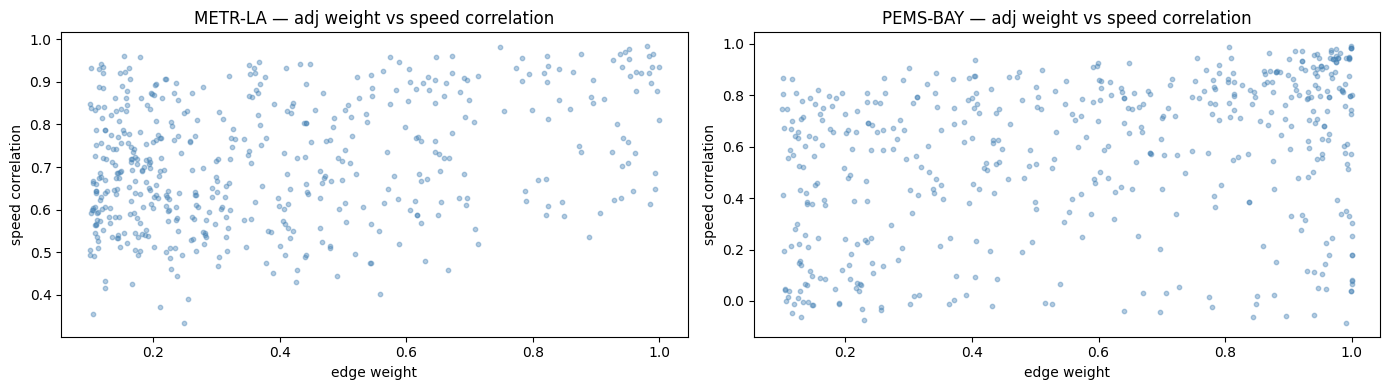

In [17]:
def analyze_weight_vs_speed_correlation(df: pd.DataFrame, adj_mx: np.ndarray, dataset: str, ax=None):
    A = adj_mx.copy()
    np.fill_diagonal(A, 0)

    rows, cols = np.where(A > 0)
    idx        = np.random.choice(len(rows), min(500, len(rows)), replace=False)
    rows, cols = rows[idx], cols[idx]

    weights     = A[rows, cols]
    speed_corrs = [df.iloc[:, r].corr(df.iloc[:, c]) for r, c in zip(rows, cols)]

    if ax is None:
        _, ax = plt.subplots()
    ax.scatter(weights, speed_corrs, alpha=0.4, s=10, color='steelblue')
    ax.set_title(f"{dataset} — adj weight vs speed correlation")
    ax.set_xlabel("edge weight")
    ax.set_ylabel("speed correlation")

fig, axes = plt.subplots(1, 2, figsize=(14, 4), tight_layout=True)
analyze_weight_vs_speed_correlation(metr_df, metr_adj_mx, "METR-LA",  ax=axes[0])
analyze_weight_vs_speed_correlation(pems_df, pems_adj_mx, "PEMS-BAY", ax=axes[1])
plt.show()

In [18]:
def interpolate_speed(df: pd.DataFrame) -> pd.DataFrame:
    """
    Replaces zeros with NaN and linearly interpolates along time axis.

    Args:
        df     : pd.DataFrame, shape (T, N), raw speed data
        dataset: dataset name for logging

    Returns:
        pd.DataFrame, shape (T, N), interpolated speed data
    """
    before_zeros = (df == 0).sum().sum()

    df_interp = df.copy()
    df_interp[df_interp == 0] = np.nan
    df_interp = df_interp.interpolate(method='linear', axis=0, limit_direction='both')

    remaining_nans = df_interp.isna().sum().sum()

    print(f"zeros replaced : {before_zeros}")
    print(f"remaining NaNs : {remaining_nans}")

    return df_interp

In [20]:
metr_df_interp = interpolate_speed(metr_df)

zeros replaced : 575302
remaining NaNs : 0


In [21]:
pems_df_interp = interpolate_speed(pems_df)

zeros replaced : 521
remaining NaNs : 0


In [22]:
# before
analyze_missing_data(metr_df, "METR-LA")
analyze_missing_data(pems_df, "PEMS-BAY")

METR-LA
	dead sensors     : 0 / 207
	empty timesteps  : 2148 / 34272 (6.3%)
	total zero values: 575302 / 7094304 (8.11%)
PEMS-BAY
	dead sensors     : 0 / 325
	empty timesteps  : 0 / 52116 (0.0%)
	total zero values: 521 / 16937700 (0.00%)


In [24]:
# after
analyze_missing_data(metr_df_interp, "METR-LA")
analyze_missing_data(pems_df_interp, "PEMS-BAY")

METR-LA
	dead sensors     : 0 / 207
	empty timesteps  : 0 / 34272 (0.0%)
	total zero values: 0 / 7094304 (0.00%)
PEMS-BAY
	dead sensors     : 0 / 325
	empty timesteps  : 0 / 52116 (0.0%)
	total zero values: 0 / 16937700 (0.00%)


In [25]:
# ─────────────────────────────────────────
# CONFIG
# ─────────────────────────────────────────
DATA_DIR    = "../datasets"
window_size = 12      # past timesteps as input
horizon     = 12      # future timesteps to predict
train_ratio = 0.7
val_ratio   = 0.1
test_ratio  = 0.2     # remainder

In [28]:
def normalize(df: pd.DataFrame):
    """Z-score normalization using global mean and std."""
    mean = df.values.mean()
    std  = df.values.std()
    return (df - mean) / std, mean, std

In [29]:
# ─────────────────────────────────────────
# ADJACENCY → edge_index + edge_attr
# ─────────────────────────────────────────
def build_edge_index_and_attr(adj_mx: np.ndarray):
    """
    Converts adjacency matrix to PyG edge_index and edge_attr.
    Sensor IDs are already mapped to 0..N-1 via adj_mx row/col indices.

    Returns:
        edge_index : torch.LongTensor,  shape [2, num_edges]
        edge_attr  : torch.FloatTensor, shape [num_edges, 1]
    """
    adj_tensor = torch.tensor(adj_mx, dtype=torch.float)
    edge_index  = adj_tensor.nonzero().t().contiguous()   # [2, num_edges]

    # remove self-loops
    mask       = edge_index[0] != edge_index[1]
    edge_index = edge_index[:, mask]

    # edge weights as attributes
    edge_attr  = adj_tensor[edge_index[0], edge_index[1]].unsqueeze(1)  # [num_edges, 1]

    print(f"edge_index : {edge_index.shape}")
    print(f"edge_attr  : {edge_attr.shape}")
    return edge_index, edge_attr

In [30]:
# ─────────────────────────────────────────
# SLIDING WINDOW → list of PyG Data objects
# ─────────────────────────────────────────
def build_pyg_data_list(
    speed:      torch.Tensor,    # (T, N) normalized speed
    edge_index: torch.Tensor,    # (2, E)
    edge_attr:  torch.Tensor,    # (E, 1)
    window_size: int,
    horizon:     int,
) -> list:
    """
    Creates one PyG Data object per sliding window:
        x : [N, window_size]  — past speeds (input)
        y : [N, horizon]      — future speeds (target)
    Node indices are 0..N-1, matching adj_mx row/col order.
    """
    data_list = []
    T = speed.shape[0]

    for t in range(window_size - 1, T - horizon):
        x = speed[t - window_size + 1 : t + 1].T        # [N, window_size]
        y = speed[t + 1           : t + 1 + horizon].T  # [N, horizon]
        data_list.append(Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y))

    print(f"total samples : {len(data_list)}")
    print(f"x shape       : {data_list[0].x.shape}")
    print(f"y shape       : {data_list[0].y.shape}")
    return data_list

In [31]:
# ─────────────────────────────────────────
# TRAIN / VAL / TEST SPLIT
# ─────────────────────────────────────────
def split_data_list(data_list: list, train_ratio=train_ratio, val_ratio=val_ratio):
    """
    Splits data_list temporally (no shuffle — time series).

    Returns:
        train_list, val_list, test_list
    """
    N      = len(data_list)
    t_end  = int(N * train_ratio)
    v_end  = int(N * (train_ratio + val_ratio))

    train  = data_list[:t_end]
    val    = data_list[t_end:v_end]
    test   = data_list[v_end:]

    print(f"train : {len(train)} samples")
    print(f"val   : {len(val)} samples")
    print(f"test  : {len(test)} samples")
    return train, val, test

In [32]:
# ─────────────────────────────────────────
# PyG DATASET WRAPPER
# ─────────────────────────────────────────
class TrafficDataset(InMemoryDataset):
    def __init__(self, data_list):
        super().__init__()
        self.data_list = data_list

    def len(self):
        return len(self.data_list)

    def get(self, idx):
        return self.data_list[idx]

In [36]:
# Check adjacency matrix indices and speed dataframe sensor ID columns alignment

df_indices = [metr_sensor_id_to_idx[s] for s in metr_df.columns]
aligned = df_indices == list(range(len(df_indices)))
print("METR-LA: Columns aligned to adjacency:", aligned)

df_indices = [pems_sensor_id_to_idx[s] for s in pems_df.columns]
aligned = df_indices == list(range(len(df_indices)))
print("PEMS-BAY: Columns aligned to adjacency:", aligned)

METR-LA: Columns aligned to adjacency: True
PEMS-BAY: Columns aligned to adjacency: True


In [39]:
def build_dataset(dataset: Literal["METR-LA", "PEMS-BAY"]):
    pyg_path = DATASET_CONFIG[dataset]["pyg_path"]
    os.makedirs(os.path.dirname(pyg_path), exist_ok=True)

    print(f"\n{'='*40}")
    print(f" {dataset}")
    print(f"{'='*40}")

    # 1. load
    print("\n[1] loading speed data")
    df = load_traffic_h5(dataset)

    # 2. interpolate
    print("\n[2] interpolating missing values")
    df = interpolate_speed(df)

    # 3. split raw df first (before normalization)
    print("\n[3] splitting")
    n     = len(df)
    t_end = int(n * train_ratio)
    v_end = int(n * (train_ratio + val_ratio))

    train_df = df.iloc[:t_end]
    val_df   = df.iloc[t_end:v_end]
    test_df  = df.iloc[v_end:]

    print(f"train : {len(train_df)} | val : {len(val_df)} | test : {len(test_df)}")

    # 4. normalize — fit only on train, apply to all
    print("\n[4] normalizing")
    mean = train_df.values.mean()
    std  = train_df.values.std()
    print(f"mean={mean:.3f}  std={std:.3f}")

    train_df = (train_df - mean) / std
    val_df   = (val_df   - mean) / std
    test_df  = (test_df  - mean) / std

    # 5. adjacency
    print("\n[5] loading adjacency matrix")
    sensor_ids, sensor_id_to_idx, adj_mx = load_adj_data(dataset)
    edge_index, edge_attr = build_edge_index_and_attr(adj_mx)

    # 6. sliding windows per split
    print("\n[6] building sliding windows")
    def to_tensor(d): return torch.tensor(d.values, dtype=torch.float32)

    train_list = build_pyg_data_list(to_tensor(train_df), edge_index, edge_attr, window_size, horizon)
    val_list   = build_pyg_data_list(to_tensor(val_df),   edge_index, edge_attr, window_size, horizon)
    test_list  = build_pyg_data_list(to_tensor(test_df),  edge_index, edge_attr, window_size, horizon)

    # 7. save
    torch.save({
        "train": train_list,
        "val":   val_list,
        "test":  test_list,
        "mean":  mean,
        "std":   std,
    }, pyg_path)
    print(f"\nsaved → {pyg_path}")

    return TrafficDataset(train_list), TrafficDataset(val_list), TrafficDataset(test_list), mean, std

In [40]:
train_metr, val_metr, test_metr, mean, std = build_dataset("METR-LA")
train_pems, val_pems, test_pems, mean, std = build_dataset("PEMS-BAY")


 METR-LA

[1] loading speed data

[2] interpolating missing values
zeros replaced : 575302
remaining NaNs : 0

[3] splitting
train : 23990 | val : 3427 | test : 6855

[4] normalizing
mean=58.452  std=12.855

[5] loading adjacency matrix
edge_index : torch.Size([2, 1515])
edge_attr  : torch.Size([1515, 1])

[6] building sliding windows
total samples : 23967
x shape       : torch.Size([207, 12])
y shape       : torch.Size([207, 12])
total samples : 3404
x shape       : torch.Size([207, 12])
y shape       : torch.Size([207, 12])
total samples : 6832
x shape       : torch.Size([207, 12])
y shape       : torch.Size([207, 12])

saved → ../datasets/processed/metr_la/metr_la.pt

 PEMS-BAY

[1] loading speed data

[2] interpolating missing values
zeros replaced : 521
remaining NaNs : 0

[3] splitting
train : 36481 | val : 5211 | test : 10424

[4] normalizing
mean=62.738  std=9.434

[5] loading adjacency matrix
edge_index : torch.Size([2, 2369])
edge_attr  : torch.Size([2369, 1])

[6] building 